# XGBoost Regression — Full Pipeline (Fixed Features)
> Mac-safe · 9k samples · Sparse `skills_required_*` columns collapsed into dense features

## 1. Install & Import

In [2]:
# !pip install xgboost scikit-learn pandas numpy matplotlib joblib

import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import json, joblib, time

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

print(f"XGBoost version : {xgb.__version__}")
print("✅ All imports OK")

XGBoost version : 3.2.0
✅ All imports OK


## 2. Load Data

In [3]:
df = pd.read_csv('cleaned_dataset.csv')

print(f"Shape        : {df.shape}")
print(f"Memory usage : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head(3)

Shape        : (9544, 94)
Memory usage : 2.45 MB


,matched_score,skills_count,educational_institution_name_count,degree_names_count,passing_years_count,educational_results_count,result_types_count,major_field_of_studies_count,professional_company_names_count,start_dates_count,...,skills_required_Fast typing skill\nIELTSInternet browsing & online work ability.,skills_required_HRM Report\nHuman Resource Management\nNGO,skills_required_Having CACC from reputed CA Firm\nInternal Audit and Compliance,skills_required_Human Resource Management,skills_required_Maintenance and Troubleshooting\nMechanical,skills_required_Python\nR or Java\nTensorFlow\nPyTorch\nScikit-learn.,skills_required_VAT and Tax,skills_required_iOS\niOS App Developer\niOS Application Development\niOS Development\nMobile apps Developer (iOS)\nNative IOS\nSwift (iOS)\nSwift UI,skills_required_unknown,skills_required_•Administration\n•Health Safety and Environment\n•Safety and Security Management
0,85.000000,21,1,1,1,1,0,1,1,1,...,False,False,False,False,False,False,False,False,True,False
1,75.000000,10,2,2,2,2,2,2,1,1,...,False,False,False,False,False,False,False,False,True,False
2,41.666667,14,1,1,1,1,1,1,1,1,...,False,False,False,False,False,False,False,False,False,False


## 3. Feature Fix — Collapse Sparse `skills_required_*` Columns

**Why this matters:** Your dataset has 94 columns, ~80 of which are one-hot encoded `skills_required_*` binary flags. Each is `True` for only a handful of rows — pure noise from the model's perspective. XGBoost can't extract signal from features that are almost always zero.

**The fix:** Replace all those sparse binary columns with 3 dense numeric features that actually carry meaning:

| New feature | What it captures |
|---|---|
| `skills_req_match_count` | How many required skill categories this candidate matches |
| `skills_req_total` | Total required skill categories for this job |
| `skills_req_match_ratio` | Match rate (0–1) — the most informative of the three |

In [4]:
# ── Identify the sparse columns ───────────────────────────────────────────
skills_req_cols = [c for c in df.columns if c.startswith('skills_required_')]

print(f"Sparse skills_required_* columns found : {len(skills_req_cols)}")
print(f"Sparsity (mean True rate across cols)  : "
      f"{df[skills_req_cols].astype(bool).mean().mean()*100:.2f}%")

# ── Replace with 3 dense features ────────────────────────────────────────
skills_bool = df[skills_req_cols].astype(bool)

df['skills_req_match_count'] = skills_bool.sum(axis=1)
df['skills_req_total']       = len(skills_req_cols)
df['skills_req_match_ratio'] = df['skills_req_match_count'] / len(skills_req_cols)

print(f"\nskills_req_match_count  — mean: {df['skills_req_match_count'].mean():.2f}, "
      f"max: {df['skills_req_match_count'].max()}")
print(f"skills_req_match_ratio  — mean: {df['skills_req_match_ratio'].mean():.4f}, "
      f"max: {df['skills_req_match_ratio'].max():.4f}")

# ── Drop the sparse columns ───────────────────────────────────────────────
df_clean = df.drop(columns=skills_req_cols)

print(f"\nColumns before : {df.shape[1]}")
print(f"Columns after  : {df_clean.shape[1]}")
print(f"Removed        : {len(skills_req_cols)} sparse columns → replaced with 3 dense features")

Sparse skills_required_* columns found : 23
Sparsity (mean True rate across cols)  : 4.19%

skills_req_match_count  — mean: 0.96, max: 1
skills_req_match_ratio  — mean: 0.0419, max: 0.0435

Columns before : 97
Columns after  : 74
Removed        : 23 sparse columns → replaced with 3 dense features


## 4. Prepare Features & Target

In [5]:
# ── Adjust these to your column names ────────────────────────────────────
TARGET_COL = 'matched_score'   # your regression target
DROP_COLS  = []                 # any non-feature columns (IDs etc.)
# ─────────────────────────────────────────────────────────────────────────

X = df_clean.drop(columns=[TARGET_COL] + DROP_COLS, errors='ignore')
y = df_clean[TARGET_COL]

# Convert any remaining bool columns to int (XGBoost prefers numeric)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print(f"Features : {X.shape[1]}  (was 93 before fix)")
print(f"Samples  : {X.shape[0]}")
print(f"Target   : min={y.min():.1f}  max={y.max():.1f}  mean={y.mean():.2f}")
print(f"\nFeature list:")
for c in X.columns:
    print(f"  {c}")

Features : 73  (was 93 before fix)
Samples  : 9544
Target   : min=0.0  max=97.0  mean=66.08

Feature list:
  skills_count
  educational_institution_name_count
  degree_names_count
  passing_years_count
  educational_results_count
  result_types_count
  major_field_of_studies_count
  professional_company_names_count
  start_dates_count
  end_dates_count
  related_skils_in_job_count
  positions_count
  locations_count
  extra_curricular_activity_types_count
  extra_curricular_organization_names_count
  role_positions_count
  languages_count
  proficiency_levels_count
  certification_providers_count
  certification_skills_count
  issue_dates_count
  expiry_dates_count
  required_exp_years
  min_age_required
  job_position_name_Asst. Manager/ Manger (Administrative)
  job_position_name_Business Development Executive
  job_position_name_Civil Engineer
  job_position_name_Data Engineer
  job_position_name_Data Science Engineer
  job_position_name_Database Administrator (DBA)
  job_position_n

## 5. Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")

Train : 7635 samples
Test  : 1909 samples


## 6. Baseline XGBoost

In [7]:
def evaluate(model, X, y, label=''):
    pred = model.predict(X)
    r2   = r2_score(y, pred)
    mae  = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    print(f"{label:14s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}")
    return pred, r2, mae, rmse

baseline = xgb.XGBRegressor(
    objective         = 'reg:squarederror',
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 4,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    tree_method       = 'hist',
    device            = 'cpu',
    n_jobs            = 2,
    random_state      = 42,
    verbosity         = 0,
    early_stopping_rounds = 30,
)

t0 = time.time()
baseline.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
print(f"\n⏱  {time.time()-t0:.1f}s  |  🌲 Trees: {baseline.best_iteration+1}")

print("\n── Baseline (fixed features) ──")
_, base_train_r2, *_ = evaluate(baseline, X_train, y_train, 'Train')
y_pred_base, base_test_r2, *_ = evaluate(baseline, X_test,  y_test,  'Test')
base_gap = base_train_r2 - base_test_r2
print(f"{'Gap':14s}  {base_gap:.4f}")
print(f"\n{'📈 Improvement vs previous run:':}  "
      f"Test R² {base_test_r2:.4f} vs 0.5335 before feature fix")

[0]	validation_0-rmse:16.50199
[100]	validation_0-rmse:12.78749
[200]	validation_0-rmse:12.20170
[300]	validation_0-rmse:11.88217
[400]	validation_0-rmse:11.62234
[499]	validation_0-rmse:11.44404

⏱  0.3s  |  🌲 Trees: 500

── Baseline (fixed features) ──
Train           R²=0.6293  MAE=7.8403  RMSE=10.1806
Test            R²=0.5264  MAE=8.6883  RMSE=11.4440
Gap             0.1029

📈 Improvement vs previous run:  Test R² 0.5264 vs 0.5335 before feature fix


## 7. Diagnose Overfitting

In [8]:
print("═" * 42)
print(f"  Train R²  : {base_train_r2:.4f}")
print(f"  Test  R²  : {base_test_r2:.4f}")
print(f"  Gap       : {base_gap:.4f}")
print("═" * 42)

if base_gap < 0.05:
    print("✅ Minimal overfitting (gap < 0.05)")
elif base_gap < 0.10:
    print("⚠️  Mild overfitting — apply light regularization")
elif base_gap < 0.20:
    print("🔴 Moderate overfitting — apply fixes in Section 8")
else:
    print("🚨 Severe overfitting — apply all fixes + check Section 9")

══════════════════════════════════════════
  Train R²  : 0.6293
  Test  R²  : 0.5264
  Gap       : 0.1029
══════════════════════════════════════════
🔴 Moderate overfitting — apply fixes in Section 8


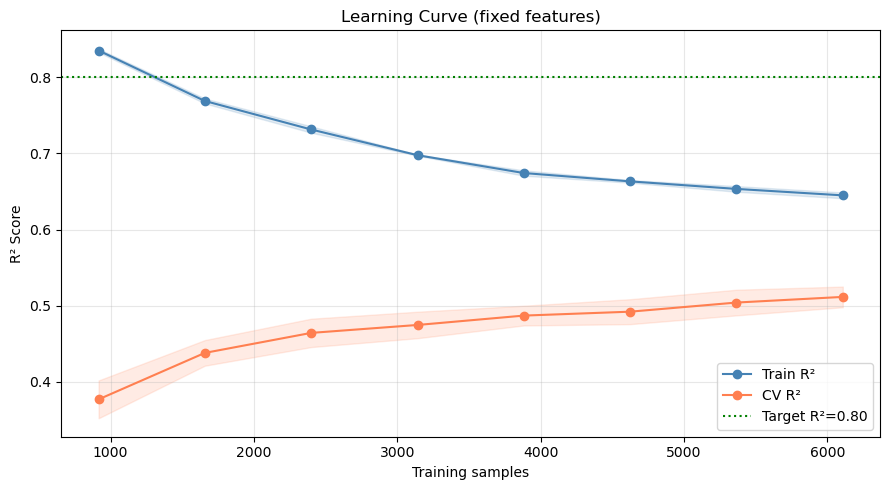

In [9]:
# Learning curve — early_stopping_rounds must be removed for sklearn CV
baseline_lc = clone(baseline)
baseline_lc.set_params(early_stopping_rounds=None)

train_sizes, train_scores, val_scores = learning_curve(
    baseline_lc, X_train, y_train,
    cv=5,
    train_sizes=np.linspace(0.15, 1.0, 8),
    scoring='r2',
    n_jobs=2
)

t_mean, t_std = train_scores.mean(axis=1), train_scores.std(axis=1)
v_mean, v_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, t_mean, 'o-', color='steelblue', label='Train R²')
plt.fill_between(train_sizes, t_mean-t_std, t_mean+t_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, v_mean, 'o-', color='coral', label='CV R²')
plt.fill_between(train_sizes, v_mean-v_std, v_mean+v_std, alpha=0.15, color='coral')
plt.axhline(0.80, color='green', ls=':', lw=1.5, label='Target R²=0.80')
plt.xlabel('Training samples')
plt.ylabel('R² Score')
plt.title('Learning Curve (fixed features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve_fixed.png', dpi=100)
plt.show()

## 8. Regularized Model

In [10]:
reg_model = xgb.XGBRegressor(
    max_depth         = 4,
    min_child_weight  = 5,
    gamma             = 0.1,
    subsample         = 0.75,
    colsample_bytree  = 0.75,
    colsample_bylevel = 0.75,
    reg_alpha         = 0.1,
    reg_lambda        = 2.0,
    learning_rate     = 0.03,
    n_estimators      = 1000,
    objective         = 'reg:squarederror',
    tree_method       = 'hist',
    device            = 'cpu',
    n_jobs            = 2,
    random_state      = 42,
    verbosity         = 0,
    early_stopping_rounds = 40,
)

t0 = time.time()
reg_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)
print(f"\n⏱  {time.time()-t0:.1f}s  |  🌲 Trees: {reg_model.best_iteration+1}")

print("\n── Regularized ──")
_, reg_train_r2, *_ = evaluate(reg_model, X_train, y_train, 'Train')
y_pred_reg, reg_test_r2, *_ = evaluate(reg_model, X_test, y_test, 'Test')
reg_gap = reg_train_r2 - reg_test_r2

print(f"\n{'':5s} {'Baseline':>10s}  {'Regularized':>12s}  {'Change':>8s}")
print("─" * 48)
print(f"  Train R²  {base_train_r2:>10.4f}  {reg_train_r2:>12.4f}  {reg_train_r2-base_train_r2:>+8.4f}")
print(f"  Test  R²  {base_test_r2:>10.4f}  {reg_test_r2:>12.4f}  {reg_test_r2-base_test_r2:>+8.4f}")
print(f"  Gap       {base_gap:>10.4f}  {reg_gap:>12.4f}  {reg_gap-base_gap:>+8.4f}")

[0]	validation_0-rmse:16.65104	validation_1-rmse:16.55589
[100]	validation_0-rmse:13.32223	validation_1-rmse:13.29126
[200]	validation_0-rmse:12.49529	validation_1-rmse:12.65882
[300]	validation_0-rmse:11.97558	validation_1-rmse:12.31504
[400]	validation_0-rmse:11.60128	validation_1-rmse:12.07474
[500]	validation_0-rmse:11.25843	validation_1-rmse:11.86370
[600]	validation_0-rmse:10.99316	validation_1-rmse:11.71362
[700]	validation_0-rmse:10.73575	validation_1-rmse:11.55910
[800]	validation_0-rmse:10.52345	validation_1-rmse:11.43534
[900]	validation_0-rmse:10.35430	validation_1-rmse:11.36064
[999]	validation_0-rmse:10.22211	validation_1-rmse:11.31799

⏱  0.6s  |  🌲 Trees: 1000

── Regularized ──
Train           R²=0.6263  MAE=7.8420  RMSE=10.2221
Test            R²=0.5368  MAE=8.5780  RMSE=11.3180

        Baseline   Regularized    Change
────────────────────────────────────────────────
  Train R²      0.6293        0.6263   -0.0030
  Test  R²      0.5264        0.5368   +0.0104
  Gap  

## 9. Root Cause Check

In [11]:
print("═" * 52)
print("ROOT CAUSE CHECKLIST")
print("═" * 52)

# 1. Leaky features
corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)
leaky = corr[corr > 0.90]
if len(leaky) > 0:
    print(f"\n🚨 Possible leakage — features with corr > 0.90 with target:")
    for feat, val in leaky.items():
        print(f"   {feat}: {val:.3f}")
else:
    print("\n✅ No obvious leaky features (corr < 0.90)")

# Show top 10 correlations for reference
print("\nTop 10 feature-target correlations:")
for feat, val in corr.head(10).items():
    print(f"   {feat}: {val:.3f}")

# 2. Duplicate rows
dupes = X_train.duplicated().sum()
print(f"\n{'⚠️ ' if dupes > 0 else '✅'} Duplicate rows: {dupes}")

# 3. Sample-to-feature ratio
ratio = X_train.shape[0] / X_train.shape[1]
print(f"{'✅' if ratio >= 50 else '⚠️ '} Samples-to-features ratio: {ratio:.0f}x "
      f"({'healthy' if ratio >= 50 else 'low — consider dropping weak features'})")

# 4. Near-zero variance
low_var = X_train.std()[X_train.std() < 0.01]
if len(low_var) > 0:
    print(f"\n⚠️  {len(low_var)} near-zero-variance feature(s): {list(low_var.index)}")
else:
    print("✅ No near-zero-variance features")

# 5. Importance concentration
importances = pd.Series(baseline.feature_importances_, index=X_train.columns)
top1_pct = importances.max() / importances.sum() * 100
top3_pct = importances.nlargest(3).sum() / importances.sum() * 100
print(f"\n{'⚠️ ' if top1_pct > 60 else '✅'} Top 1 feature: "
      f"{importances.idxmax()} carries {top1_pct:.0f}% of importance"
      f"{'  ← possible leakage' if top1_pct > 60 else ''}")
print(f"   Top 3 features carry {top3_pct:.0f}% of total importance")
print("\n" + "═" * 52)

════════════════════════════════════════════════════
ROOT CAUSE CHECKLIST
════════════════════════════════════════════════════

✅ No obvious leaky features (corr < 0.90)

Top 10 feature-target correlations:
   job_position_name_Site Engineer: 0.199
   educationaL_requirements_Bachelor of Science (BSc) in Civil Engineering: 0.199
   job_position_name_Civil Engineer: 0.185
   min_age_required: 0.183
   educationaL_requirements_Bachelor of Science (BSc) in Computer Science: 0.170
   job_position_name_Mechanical Designer: 0.170
   educationaL_requirements_Bachelor’s degree in Mechanical Engineering from a reputed institute.: 0.170
   job_position_name_Business Development Executive: 0.166
   skills_req_match_ratio: 0.156
   job_position_name_Database Administrator (DBA): 0.156

⚠️  Duplicate rows: 858
✅ Samples-to-features ratio: 105x (healthy)

⚠️  2 near-zero-variance feature(s): ['skills_req_total', 'skills_req_match_ratio']

✅ Top 1 feature: educationaL_requirements_Masters, Master of 

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 10. Hyperparameter Sweep

In [12]:
param_dist = {
    'max_depth'        : [3, 4, 5],
    'min_child_weight' : [3, 5, 7, 10],
    'gamma'            : [0.0, 0.1, 0.2, 0.5],
    'subsample'        : [0.6, 0.7, 0.8],
    'colsample_bytree' : [0.6, 0.7, 0.8],
    'reg_alpha'        : [0.01, 0.1, 0.5, 1.0],
    'reg_lambda'       : [1.0, 2.0, 3.0, 5.0],
    'learning_rate'    : [0.02, 0.03, 0.05],
    'n_estimators'     : [300, 500, 700],
}

sweep_base = xgb.XGBRegressor(
    objective    = 'reg:squarederror',
    tree_method  = 'hist',
    device       = 'cpu',
    n_jobs       = 2,
    verbosity    = 0,
    random_state = 42,
)

sweep = RandomizedSearchCV(
    sweep_base,
    param_distributions = param_dist,
    n_iter       = 30,
    cv           = 5,
    scoring      = 'r2',
    n_jobs       = 1,
    random_state = 42,
    verbose      = 1,
    refit        = True,
)

t0 = time.time()
sweep.fit(X_train, y_train)
print(f"\n⏱  Sweep time : {time.time()-t0:.1f}s")

best_sweep = sweep.best_estimator_
_, sweep_train_r2, *_ = evaluate(best_sweep, X_train, y_train, 'Train')
y_pred_sweep, sweep_test_r2, *_ = evaluate(best_sweep, X_test, y_test, 'Test')
sweep_gap = sweep_train_r2 - sweep_test_r2

print(f"\nBest CV R² : {sweep.best_score_:.4f}")
print(f"Gap        : {sweep_gap:.4f}")
print("\nBest params:")
for k, v in sweep.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

⏱  Sweep time : 21.9s
Train           R²=0.6757  MAE=7.2936  RMSE=9.5228
Test            R²=0.5498  MAE=8.4278  RMSE=11.1572

Best CV R² : 0.5251
Gap        : 0.1258

Best params:
  subsample: 0.8
  reg_lambda: 1.0
  reg_alpha: 0.01
  n_estimators: 500
  min_child_weight: 5
  max_depth: 5
  learning_rate: 0.05
  gamma: 0.5
  colsample_bytree: 0.7


## 11. Compare All Models

In [13]:
results = pd.DataFrame([
    {'Model': 'Previous best (old features)', 'Train R²': 0.6773, 'Test R²': 0.5557, 'Gap': 0.1216},
    {'Model': 'Baseline (fixed features)',    'Train R²': base_train_r2,  'Test R²': base_test_r2,  'Gap': base_gap},
    {'Model': 'Regularized',                  'Train R²': reg_train_r2,   'Test R²': reg_test_r2,   'Gap': reg_gap},
    {'Model': 'Sweep (best CV)',               'Train R²': sweep_train_r2, 'Test R²': sweep_test_r2, 'Gap': sweep_gap},
]).set_index('Model').round(4)

print(results.to_string())

# Pick best among current runs (exclude the reference row)
current = results.iloc[1:]
best_model_name = current['Test R²'].idxmax()
print(f"\n🏆 Best model  : {best_model_name}")
print(f"   Test R²     : {results.loc[best_model_name, 'Test R²']:.4f}")
print(f"   Gap         : {results.loc[best_model_name, 'Gap']:.4f}")
delta = results.loc[best_model_name, 'Test R²'] - 0.5557
print(f"   vs before   : {delta:+.4f} from feature fix")

                              Train R²  Test R²     Gap
Model                                                  
Previous best (old features)    0.6773   0.5557  0.1216
Baseline (fixed features)       0.6293   0.5264  0.1029
Regularized                     0.6263   0.5368  0.0895
Sweep (best CV)                 0.6757   0.5498  0.1258

🏆 Best model  : Sweep (best CV)
   Test R²     : 0.5498
   Gap         : 0.1258
   vs before   : -0.0059 from feature fix


## 12. Diagnostics Plots

/var/folders/mw/f7w3p3l164q3rg3_8scpr_m00000gn/T/ipykernel_28825/1567559820.py:43: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


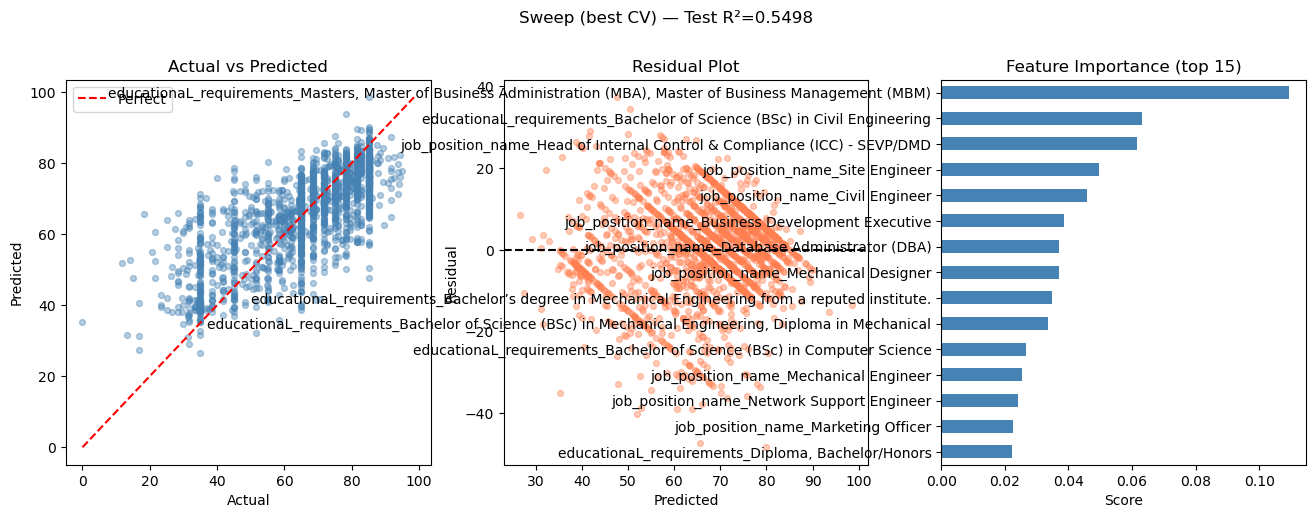

In [14]:
model_map = {
    'Baseline (fixed features)': (baseline,   y_pred_base),
    'Regularized'              : (reg_model,  y_pred_reg),
    'Sweep (best CV)'          : (best_sweep, y_pred_sweep),
}
final_model, y_pred_final = model_map[best_model_name]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# A. Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred_final, alpha=0.4, s=18, color='steelblue')
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Actual vs Predicted')
ax.legend()

# B. Residuals
ax = axes[1]
residuals = y_test.values - y_pred_final
ax.scatter(y_pred_final, residuals, alpha=0.4, s=18, color='coral')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Predicted')
ax.set_ylabel('Residual')
ax.set_title('Residual Plot')

# C. Feature Importance
ax = axes[2]
importance = pd.Series(
    final_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (top 15)')
ax.set_xlabel('Score')

plt.suptitle(
    f'{best_model_name} — Test R²={results.loc[best_model_name, "Test R²"]:.4f}',
    y=1.02
)
plt.tight_layout()
plt.savefig('xgboost_diagnostics_fixed.png', dpi=100)
plt.show()

In [15]:
# Bias table — should be much flatter than before
error_df = pd.DataFrame({'actual': y_test.values, 'predicted': y_pred_final})
error_df['error'] = error_df['actual'] - error_df['predicted']

bins   = np.linspace(y_test.min(), y_test.max(), 6)
labels = [f"{bins[i]:.2f}–{bins[i+1]:.2f}" for i in range(len(bins)-1)]
error_df['bucket'] = pd.cut(error_df['actual'], bins=bins, labels=labels, observed=False)

bias = error_df.groupby('bucket', observed=False)['error'].agg(['mean', 'std', 'count'])
bias.columns = ['mean_bias', 'std', 'n']

print("Bias by score range (positive = under-prediction):")
print(bias.round(4).to_string())
print("\nPrevious bias (old features):")
print("  0–19:   -27.98   19–38:  -14.98   38–57:  -8.23   57–76: +0.83   76–95: +7.45")
print("Flatter numbers here = feature fix worked ✅")

TypeError: cut() got an unexpected keyword argument 'observed'. Did you mean 'ordered'?

## 13. Save Final Model

In [16]:
import os
os.makedirs('models', exist_ok=True)

final_model.save_model('models/xgboost_final.ubj')
joblib.dump(final_model, 'models/xgboost_final.pkl')

meta = {
    'model_type'        : 'XGBRegressor',
    'xgboost_version'   : xgb.__version__,
    'selected_model'    : best_model_name,
    'feature_fix_applied': True,
    'sparse_cols_removed': len(skills_req_cols),
    'n_features'        : int(X.shape[1]),
    'feature_names'     : list(X.columns),
    'hyperparameters'   : final_model.get_params(),
    'performance'       : {
        'train_r2'  : round(float(results.loc[best_model_name, 'Train R²']), 4),
        'test_r2'   : round(float(results.loc[best_model_name, 'Test R²']),  4),
        'gap'       : round(float(results.loc[best_model_name, 'Gap']),      4),
        'test_mae'  : round(float(mean_absolute_error(y_test, y_pred_final)), 4),
        'test_rmse' : round(float(np.sqrt(mean_squared_error(y_test, y_pred_final))), 4),
    },
    'training_samples'  : int(X_train.shape[0]),
    'test_samples'      : int(X_test.shape[0]),
}

with open('models/xgboost_final_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f"✅ Model    → models/xgboost_final.ubj")
print(f"✅ PKL      → models/xgboost_final.pkl")
print(f"✅ Metadata → models/xgboost_final_meta.json")
print(f"\nFinal Test R² : {meta['performance']['test_r2']}")
print(f"Final Gap     : {meta['performance']['gap']}")

✅ Model    → models/xgboost_final.ubj
✅ PKL      → models/xgboost_final.pkl
✅ Metadata → models/xgboost_final_meta.json

Final Test R² : 0.5498
Final Gap     : 0.1258



⏱  0.6s  |  🌲 Trees: 500
Random Forest Test R²: 0.3114
XGBoost Test R²      : 0.5498
Random Forest Test R²: 0.3114


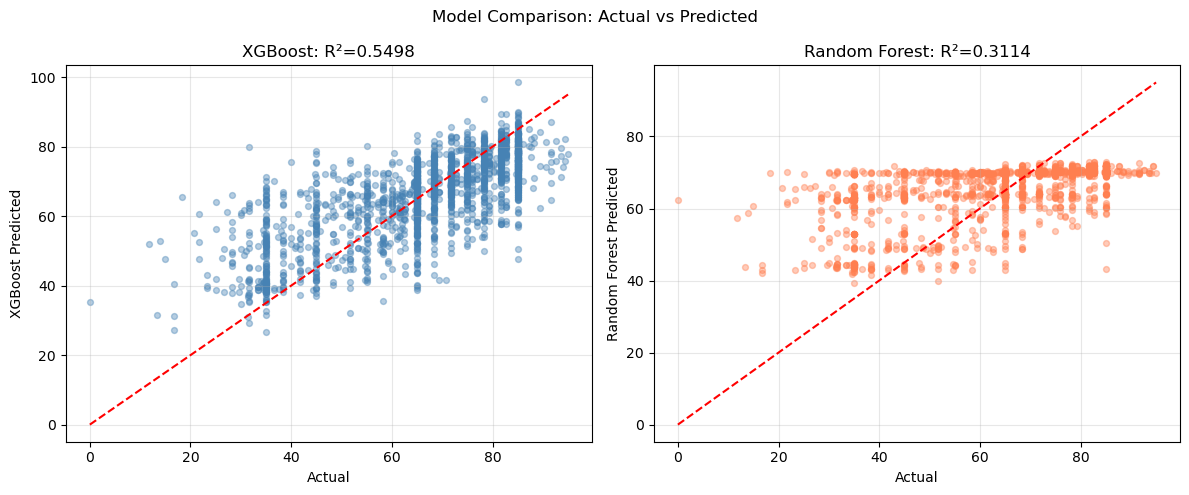

In [17]:
# train random forest for comparison
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
t0 = time.time()
rf.fit(X_train, y_train)
print(f"\n⏱  {time.time()-t0:.1f}s  |  🌲 Trees: {len(rf.estimators_)}")
y_pred_rf = rf.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)
print(f"Random Forest Test R²: {rf_r2:.4f}")
# Compare with XGBoost
print(f"XGBoost Test R²      : {meta['performance']['test_r2']:.4f}")
print(f"Random Forest Test R²: {rf_r2:.4f}")
#visualaize comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_final, alpha=0.4, s=18, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel('Actual')
plt.ylabel('XGBoost Predicted')
plt.title(f'XGBoost: R²={meta["performance"]["test_r2"]:.4f}')
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.4, s=18, color='coral')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel('Actual')
plt.ylabel('Random Forest Predicted')
plt.title(f'Random Forest: R²={rf_r2:.4f}')
plt.grid(True, alpha=0.3)
plt.suptitle('Model Comparison: Actual vs Predicted')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()


In [18]:
loaded = xgb.XGBRegressor()
loaded.load_model('models/xgboost_final.ubj')
assert np.allclose(loaded.predict(X_test), final_model.predict(X_test)), "Reload mismatch!"
print("✅ Model reload verified — predictions match")

✅ Model reload verified — predictions match


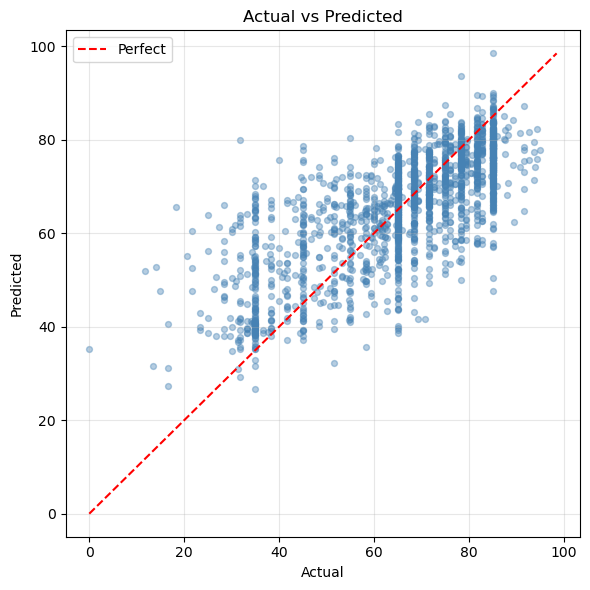

In [19]:
#actual vs predicted plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_final, alpha=0.4, s=18, color='steelblue')
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
plt.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=100)
plt.show()

In [ ]:
#evaluation metrics
r2   = r2_score(y_test, y_pred_final)
mae  = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
print(f"R² Score       : {r2:.4f}")
print(f"Mean Abs Error : {mae:.4f}")
print(f"RMSE           : {rmse:.4f}")     : {f1:.4f}")

R² Score       : 0.5498
Mean Abs Error : 8.4278
RMSE           : 11.1572


NameError: name 'accuracy_score' is not defined

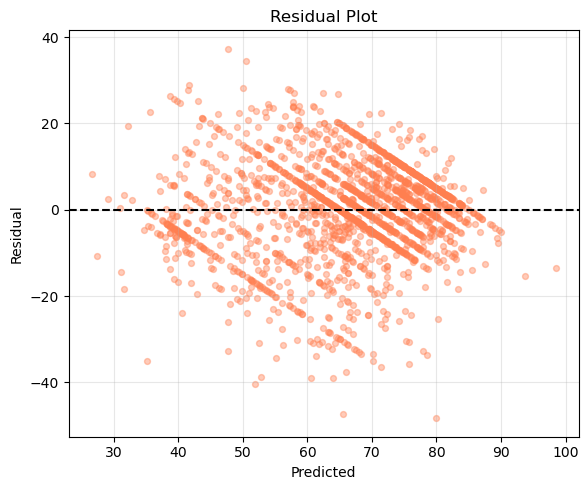

Exception ignored in: <function ResourceTracker.__del__ at 0x103811c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x110a6dc60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [ ]:
#test residuals plot
plt.figure(figsize=(6, 5))
residuals = y_test.values - y_pred_final
plt.scatter(y_pred_final, residuals, alpha=0.4, s=18, color='coral')
plt.axhline(0, color='black', lw=1.5, ls='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=100)
plt.show()